## **Name:** Aaditi Parab

## **Computing ID:** pmh3sz

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

!pip install lime
from lime import lime_tabular
from sklearn.inspection import permutation_importance

# Below is a new package needed for this lab
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Lab 3: Decision Trees and Random Forests (100 Points)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/17jL6-gLQWYkZJZGzAduIlU4YET0u2Ek-?usp=sharing)

The goal of this lab is to optimize Decision Tree and Random Forest models using the provided dataset on census level data. Your goal is to build a Random Forest Classifier to be able to predict income levels above or below 50k.

The guidance this week is less prescriptive in terms of steps, so use the skills you have gained over the semester to build and evaluate your models. You will be graded on your model building, interpretation of the results and explanation of model selection. As always, you are welcome to rely on your classmates but submit your own code. Lastly, there are likely several correct approaches involving a variety of different conclusions, just make sure your conclusions are supported by your approach.


The dataset should be familiar as it's the census data, on 48,000+ individuals with a variety of variables and a target variable for above or below 50k in salary.

![](https://www.coopercenter.org/sites/default/files/styles/wide/public/wordpress_import/Figure1CesnsuBlog2-1024x512_0.png?itok=DwYqkfFm)

Look through the data dictionary at its source link: https://archive.ics.uci.edu/ml/datasets/Adult

# **Part 1: Data Preparation and EDA (15 points)**

In a text cell, answer the following exploratory questions and support your observations with any code, if needed.

## **Question 1 (2 points):**
## Read in the features (X) as a Pandas DataFrame. Show the first 5 rows of the features. How many rows do you have?



In [58]:
# Fetch dataset
adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

In [59]:
print("number of rows: "+str(len(X)))
X.head()


number of rows: 48842


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


**There are a total of 48842 rows.**

## **Question 2 (2 points):**
## Are there any potential issues in the data or target that need to be corrected? Why are they issues? What specific method would you use to correct them and why?

## Consider using code and reading the data description (https://archive.ics.uci.edu/dataset/2/adult) to explore:

*   Assumptions and ranges of collected data
- ages: >16 (must not be children)
- agi: >100 (removes points with very low incomes under 100)
- final weight (AFNLWGT) >1
- hours worked: >0 (must be employed to make money)

*   Missing values (impute? drop?)
- workclass, occupation, native country, impute
- drop fnlwgt feauture, 

*   Numerical data types represented as strings
- none

*   Encoding categorical data appropriately
- one hot encoding

*   Normalization- not required
*   Standardization- not required

## You will not need to consider feature imbalances or sampling in part 1 or 2 of the lab.

**Potential Issues:** Potential issues I've identified are....
1. MISSING VALUES
Some categorical features such as workclass, occupation, and native country have missing values and NaNs. The decision tree model may not be able to handle these missing values but this can be fixed by imputing missing values with the mode of features.
2. AFNLWGT
This feature is likely not correlated with salary and should be removed. 
3. ENCODING
Categorical text features must be converted to numerical before modeling the tree. One hot encoding can convert these categorical variables into binary
 

## **Question 3 (6 points):**
## Preprocess the data according to the issues and correction methods you've identified. Save the new features and target variable (if necessary) as X_clean and y_clean.

In [60]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

#1. missing values
X=X.replace(['null', '','-', '?'], np.nan)
mode_imputer = SimpleImputer(strategy='most_frequent')
missing_val_col = [ 'workclass', 'occupation', 'native-country']
X[missing_val_col] = mode_imputer.fit_transform(X[missing_val_col])

#2 drop fnlwgt
X = X.drop(columns=['fnlwgt'])

#3 encoding categorical data
categorical_cols = X.select_dtypes(include='object').columns.tolist()

if len(categorical_cols)>0:
    encoder = OneHotEncoder(sparse_output=False)
    encoded_features = encoder.fit_transform(X[categorical_cols])

    encoded_df=pd.DataFrame(
        encoded_features,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=X.index)
    X_clean = pd.concat([X.drop(columns=categorical_cols), encoded_df], axis=1)

else:
    X_clean=X

#X = pd.concat([X, encoded_df], axis=1)
#X_clean = X.drop(categorical_cols, errors='ignore')

target_col = y['income']
y_clean = target_col.str.strip().str.replace('.', '', regex=False)







## **Question 4 (5 points):**
## Create 2 versions of y_clean to create a new target response of whether income is above or below $50,000 for classification.

1.   **y_clean_binary:** Recode y_clean to be 1 if the target is over or equal to
2.   **y_clean_string:** Recode y_clean to be "Above or Equal" if the target is over or equal to 50,000 and "Below" if under.



In [61]:
y_clean_binary = y_clean.replace({'<=50K': 0, '>50K': 1})

y_clean_string = y_clean.replace({'<=50K': 'Below', '>50K': 'Above or Equal'})

'''print(y_clean_binary.value_counts())
print(y_clean_string.value_counts())'''


C:\Users\aadit\AppData\Local\Temp\ipykernel_25628\3917996250.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_clean_binary = y_clean.replace({'<=50K': 0, '>50K': 1})


'print(y_clean_binary.value_counts())\nprint(y_clean_string.value_counts())'

# **Part 2: Decision Tree Pruning, Tuning and Evaluation (30 Points)**

## **Question 1 (5 points):**
## Create a function to take in a feature variable (X) and (y). In this function, create a train test split with a random seed of 3001.

## Use a vanilla decision tree model to fit the model on the train set and predict on the test set. Print the precision, recall, and accuracy of the model after prediction.

## Test that your function runs on both y_clean_binary and y_clean_string. For any of the following questions, you may use whichever y_clean variable you'd like.


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier


def tree_fun(X,y):
    #train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3001)
    
    #vanilla decision tree model
    vanilla_tree=DecisionTreeClassifier(random_state=3001)
    vanilla_tree.fit(X_train, y_train)
    y_pred = vanilla_tree.predict(X_test)
    
#need to set pos labels correctly based on binary or string
    if y_test.dtype == 'O':  
        pos = 'Above or Equal'
    else:
        pos = 1
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', pos_label=pos)
    rec = recall_score(y_test, y_pred, average='binary',pos_label=pos)
    
    print("accuracy: "+str(acc))
    print("precision: "+str(prec))
    print("recall: "+str(rec))

print('y_clean_string results:') 
tree_fun(X_clean, y_clean_string)
print()
print('y_clean_binary results:')
tree_fun(X_clean,y_clean_binary)
    

y_clean_string results:
accuracy: 0.8177847539752952
precision: 0.615046677649643
recall: 0.6385404789053591

y_clean_binary results:
accuracy: 0.8188084351327374
precision: 0.6278860569715142
recall: 0.5969213226909921


## **Question 2 (5 points):**
## Adjust your function to include some plotting features. After your prediction code, plot:

1.   A visualization of the resulting decision tree
2.   A confusion matrix of the results

## Your tree might be overwhelming or very large! If it is too large to be interpreted, constrain the max_depth parameter manually to 5 or less.

y_clean_string results:
accuracy: 0.846584317204668
precision: 0.7596867271228359
recall: 0.5253705815279361


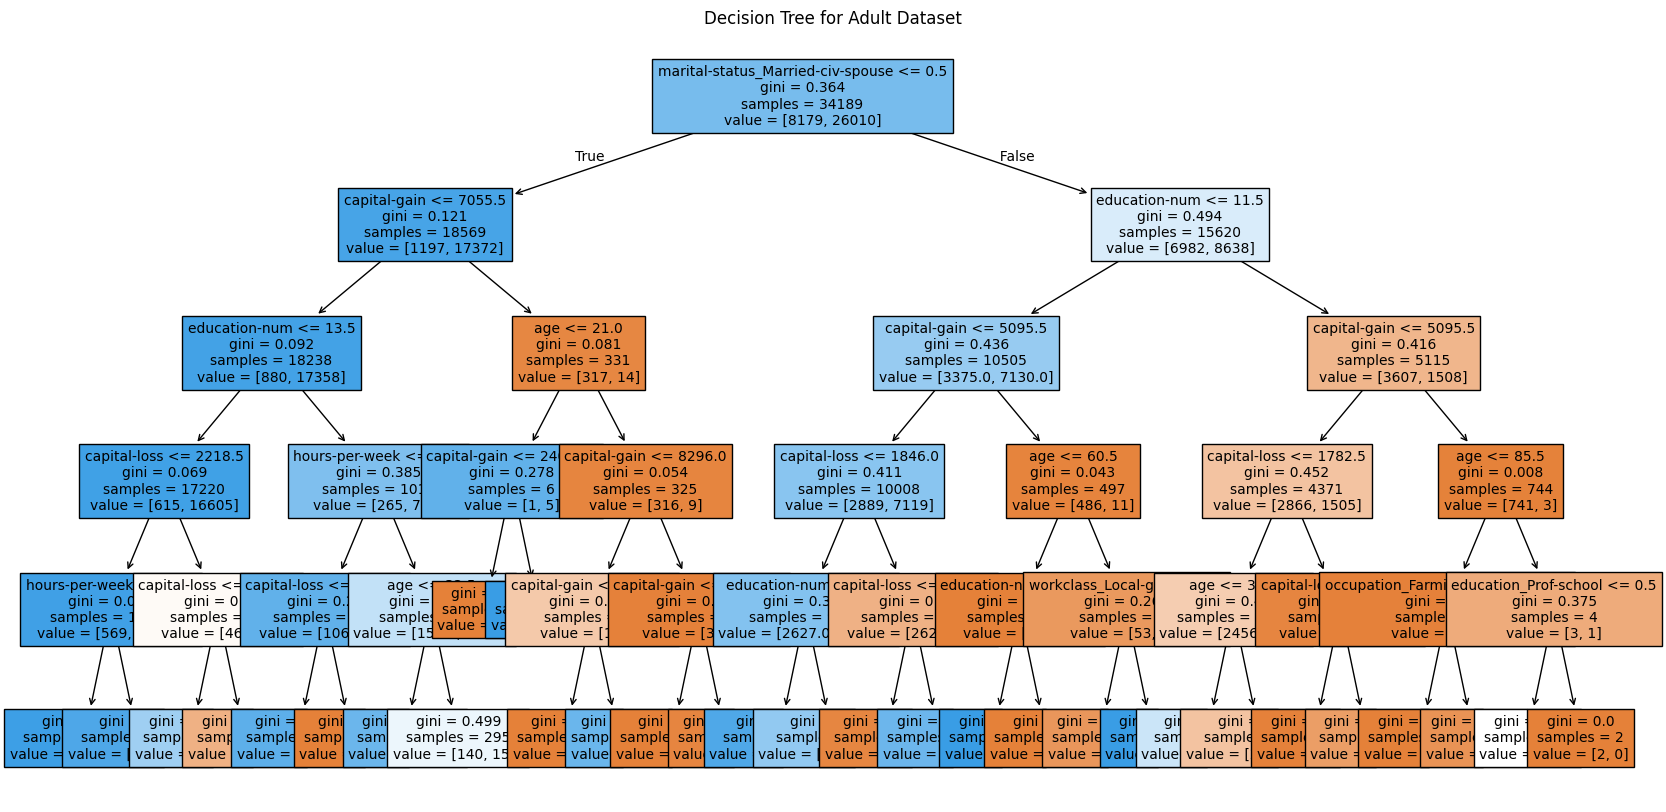

[[ 1843  1665]
 [  583 10562]]

y_clean_binary results:
accuracy: 0.8465160717941719
precision: 0.7595876288659794
recall: 0.5250855188141391


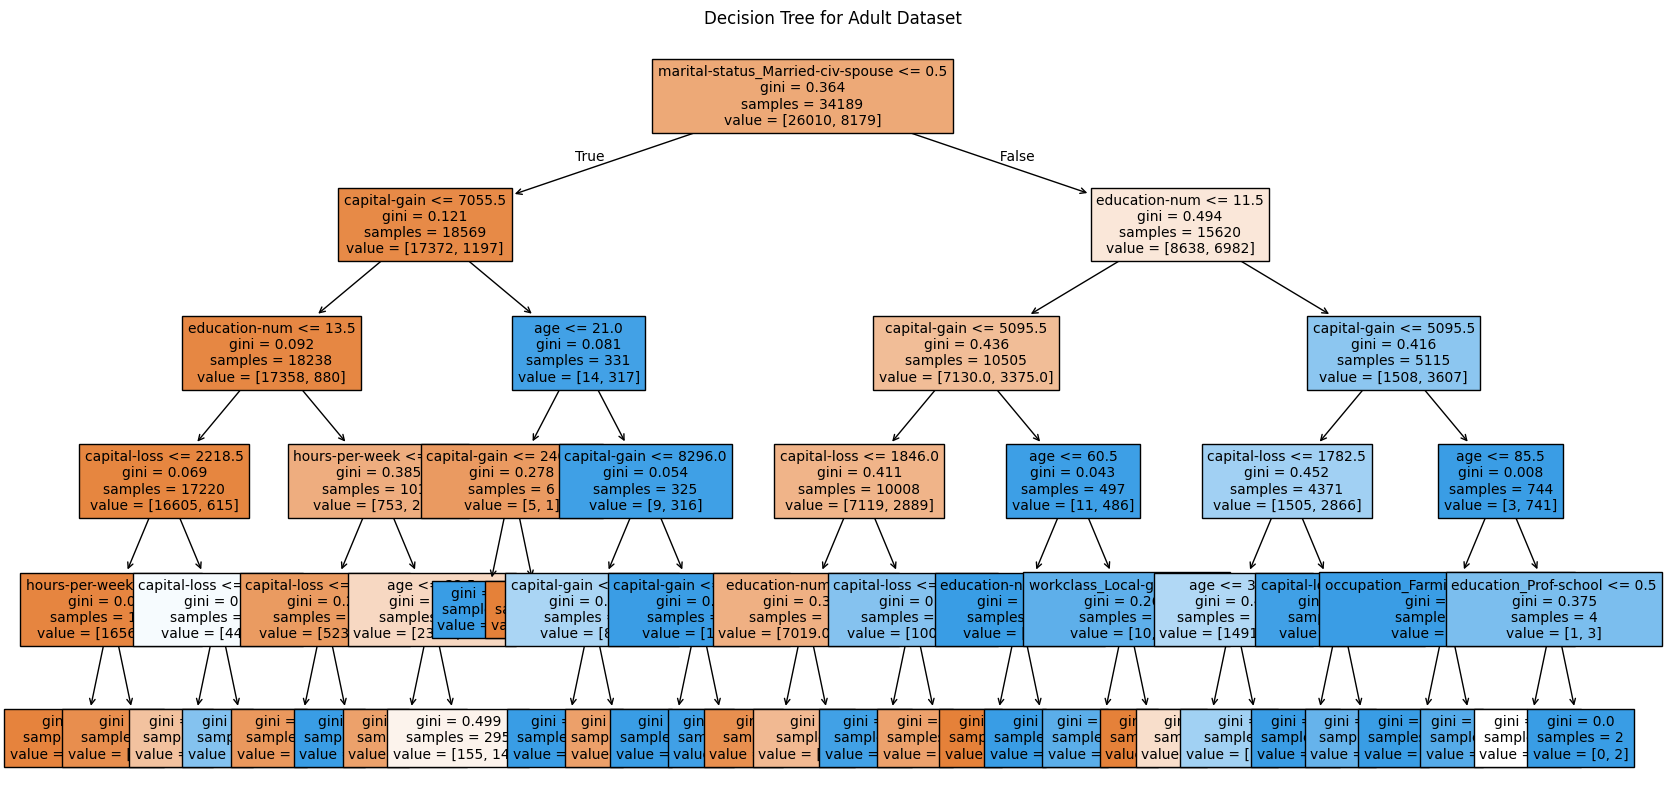

[[10562   583]
 [ 1666  1842]]


In [63]:
import sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree


def tree_fun(X,y):
    #train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3001)
    
    #vanilla decision tree model
    treemodel=DecisionTreeClassifier(random_state=3001, max_depth=5)
    treemodel.fit(X_train, y_train)
    y_pred = treemodel.predict(X_test)
    
    #need to set pos labels correctly based on binary or string
    if y_test.dtype == 'O':  
        pos = 'Above or Equal'
    else:
        pos = 1
    
    #get/print metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', pos_label=pos)
    rec = recall_score(y_test, y_pred, average='binary',pos_label=pos)
    
    print("accuracy: "+str(acc))
    print("precision: "+str(prec))
    print("recall: "+str(rec))
    
    ##adding in visualization of the tree
    plt.figure(figsize=(20,10))
    plot_tree(treemodel, filled=True, feature_names=X_clean.columns, fontsize=10)
    plt.title('Decision Tree for Adult Dataset')
    plt.show()
    
    
    cm=sklearn.metrics.confusion_matrix(y_test, y_pred, sample_weight=None, normalize=None)
    print(cm)
 
#call the function   
print('y_clean_string results:') 
tree_fun(X_clean, y_clean_string)
print()
print('y_clean_binary results:')
tree_fun(X_clean,y_clean_binary)


    







## **Question 3 (5 points):**
## Create a sorted list of feature importances and comment on the top features.Are there a few that seem to be more important than the others?

## Plot your feature importances in a horizontal or vertical bar chart from most to least important. Label each bar with its feature importance rounded to the nearest integer (ie: 30%).

y_clean_binary results:
accuracy: 0.8465160717941719
precision: 0.7595876288659794
recall: 0.5250855188141391


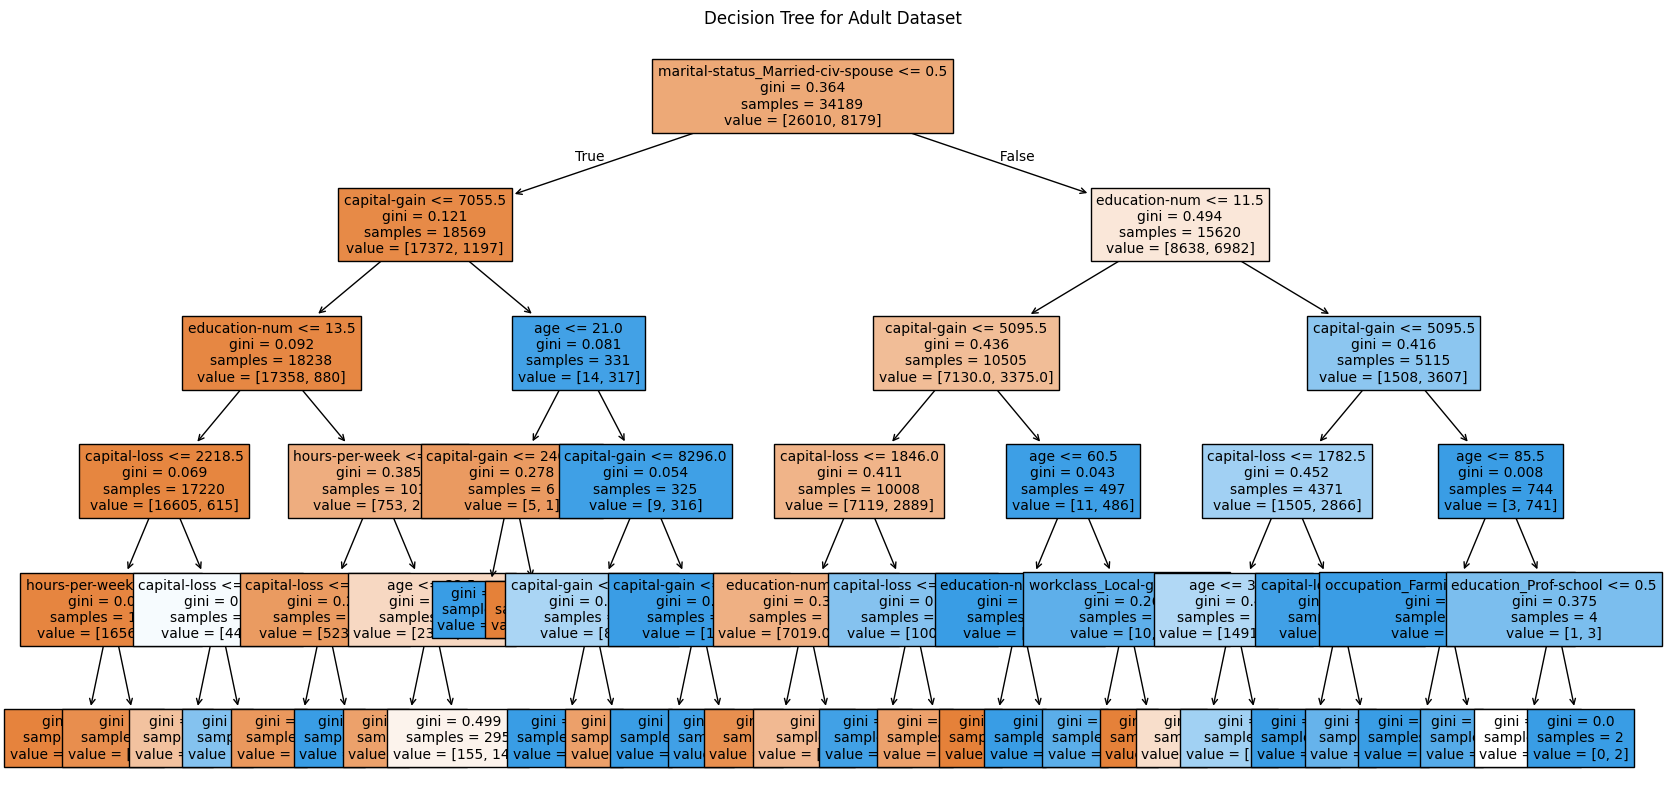

confusion matrix:
[[10562   583]
 [ 1666  1842]]

marital-status_Married-civ-spouse    46
education-num                        23
capital-gain                         21
capital-loss                          7
age                                   1
hours-per-week                        1
dtype: int64


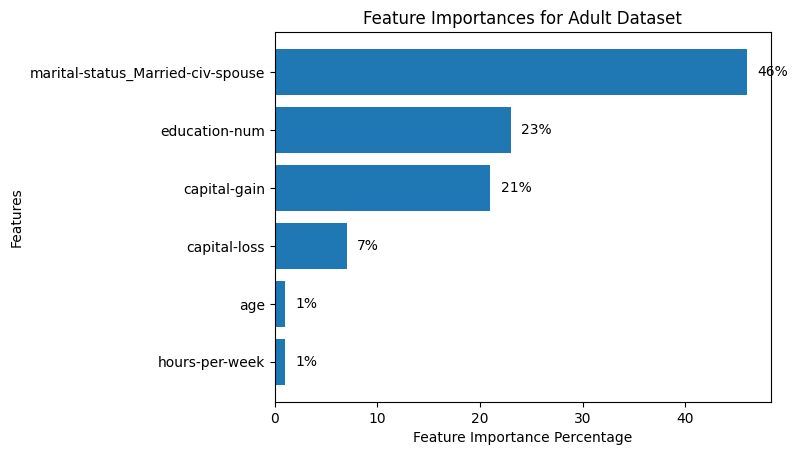

In [64]:
def tree_fun(X,y):
    #TRAIN TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3001)
    
    #DECISION TREE MODEL
    treemodel=DecisionTreeClassifier(random_state=3001, max_depth=5)
    treemodel.fit(X_train, y_train)
    y_pred = treemodel.predict(X_test)
    
    #need to set pos labels correctly based on binary or string
    if y_test.dtype == 'O':  
        pos = 'Above or Equal'
    else:
        pos = 1
    
    #OBTAIN AND PRINT METRICS (accuracy, precision, recall)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', pos_label=pos)
    rec = recall_score(y_test, y_pred, average='binary',pos_label=pos)
    
    print("accuracy: "+str(acc))
    print("precision: "+str(prec))
    print("recall: "+str(rec))
    
    ##VISUALIZATION OF TREE
    plt.figure(figsize=(20,10))
    plot_tree(treemodel, filled=True, feature_names=X_clean.columns, fontsize=10)
    plt.title('Decision Tree for Adult Dataset')
    plt.show()
    
    ##CONFUSION MATRIX
    cm=sklearn.metrics.confusion_matrix(y_test, y_pred, sample_weight=None, normalize=None)
    print('confusion matrix:')
    
    print(cm)
    print()
    
    
    #FEATURE IMPORTANCES LIST AND PLOTTING
    feat_imp = pd.Series(treemodel.feature_importances_, index=X_clean.columns)
    feat_imp = feat_imp.sort_values(ascending=False)  #sort the list

    percentage = (feat_imp * 100).round(0).astype(int) #makes percentages and round
    top = percentage.head(6)
    print(top) #print top 6 most important
    
    #bar plot of feature importances
    plt.figure()
    plt.barh(top.index[::-1],top.values[::-1])
    plt.xlabel('Feature Importance Percentage')
    plt.ylabel('Features')
    plt.title('Feature Importances for Adult Dataset')
    for i, (val, name) in enumerate(zip(top.values[::-1], top.index[::-1])): #used chatgpt to edit this
        plt.text(val + 1, i, f"{val}%", va='center')
    
    plt.show()
    
    
    
    
    
    

print('y_clean_binary results:')
tree_fun(X_clean,y_clean_binary)


## **Question 4 (5 points):**
## Write at least 5 sentences interpreting the results of your decision tree, confusion matrix, and feature importance visualizations.

## Is there any aspect of your results that you are uncertain or unsure of?

**My results show...
Confusion matrix: The model correctly classified a high number of true negatives, individuals with income<50k. There were a high number of false negatives which shows that many high income data points are being classified as low income. This aligns with the high accuracy and lower recall.
The feature importances and decision tree show that marital status, education, and capital gain were top indicators of income being over or under 50k. Features not shown on the plot have feature importance under 1%, indicating that just a few top features drive the prediction. I am unsure of why martial status is showing as the top feature because I would have guessed education or age.
**


## **Question 5 (5 points):**
## Finally, we will create a new function to tune your decision tree to get more accurate and efficient results. Update your function to take in several new parameters with these default values:
* criterion_val ='gini'
* splitter_val ='best'
* max_depth_val = None
* min_samples_split_val = 2
* min_samples_leaf_val =1

## Pass your own variable into the decision tree by specifying what sklearn parameter you are trying to tune. This will simply be the parameter without the "_val" suffix.

## **For example, if your vanilla decision tree variable is called clf, you would adjust it like this:**
`clf = DecisionTreeClassifier(criterion=criterion_val, splitter=splitter_val, ...)`

In [65]:
def tree_fun(X,y, criterion_val ='gini', splitter_val ='best', max_depth_val = None, min_samples_split_val = 2, min_samples_leaf_val =1):
    #TRAIN TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3001)
    
    #DECISION TREE MODEL (add parameters)
    treemodel=DecisionTreeClassifier(criterion=criterion_val, splitter=splitter_val, max_depth=max_depth_val, min_samples_split=min_samples_split_val, min_samples_leaf=min_samples_leaf_val, random_state=3001)
    treemodel.fit(X_train, y_train)
    y_pred = treemodel.predict(X_test)
    
    #need to set pos labels correctly based on binary or string
    if y_test.dtype == 'O':  
        pos = 'Above or Equal'
    else:
        pos = 1
    
    #OBTAIN AND PRINT METRICS (accuracy, precision, recall)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', pos_label=pos)
    rec = recall_score(y_test, y_pred, average='binary',pos_label=pos)
    
    print("accuracy: "+str(acc))
    print("precision: "+str(prec))
    print("recall: "+str(rec))
    
    ##VISUALIZATION OF TREE
    plt.figure(figsize=(20,10))
    plot_tree(treemodel, filled=True, feature_names=X_clean.columns, fontsize=10)
    plt.title('Decision Tree for Adult Dataset')
    plt.show()
    
    ##CONFUSION MATRIX
    cm=sklearn.metrics.confusion_matrix(y_test, y_pred, sample_weight=None, normalize=None)
    print('confusion matrix:')
    
    print(cm)
    print()
    
    
    #FEATURE IMPORTANCES LIST AND PLOTTING
    feat_imp = pd.Series(treemodel.feature_importances_, index=X_clean.columns)
    feat_imp = feat_imp.sort_values(ascending=False)  #sort the list

    percentage = (feat_imp * 100).round(0).astype(int) #makes percentages and round
    top = percentage.head(6)
    print(top) #print top 6 most important
    
    #bar plot of feature importances
    plt.figure()
    plt.barh(top.index[::-1],top.values[::-1])
    plt.xlabel('Feature Importance Percentage')
    plt.ylabel('Features')
    plt.title('Feature Importances for Adult Dataset')
    for i, (val, name) in enumerate(zip(top.values[::-1], top.index[::-1])): #used chatgpt to edit this
        plt.text(val + 1, i, f"{val}%", va='center')
    
    plt.show()

## **Question 6 (5 points):**

## Call your new function with either clean y variable at least 3 times. Each time, vary the values for all the parameters and examine its effects on your tree, confusion matrix, and metrics.

## You will likely want to look at documentation to see accepted values:  
###https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

## Why did you pick the values you did? What combination had the best effect on accuracy? Were you surprised by any of the results?

accuracy: 0.8436497645533337
precision: 0.719595813785637
recall: 0.5684150513112884


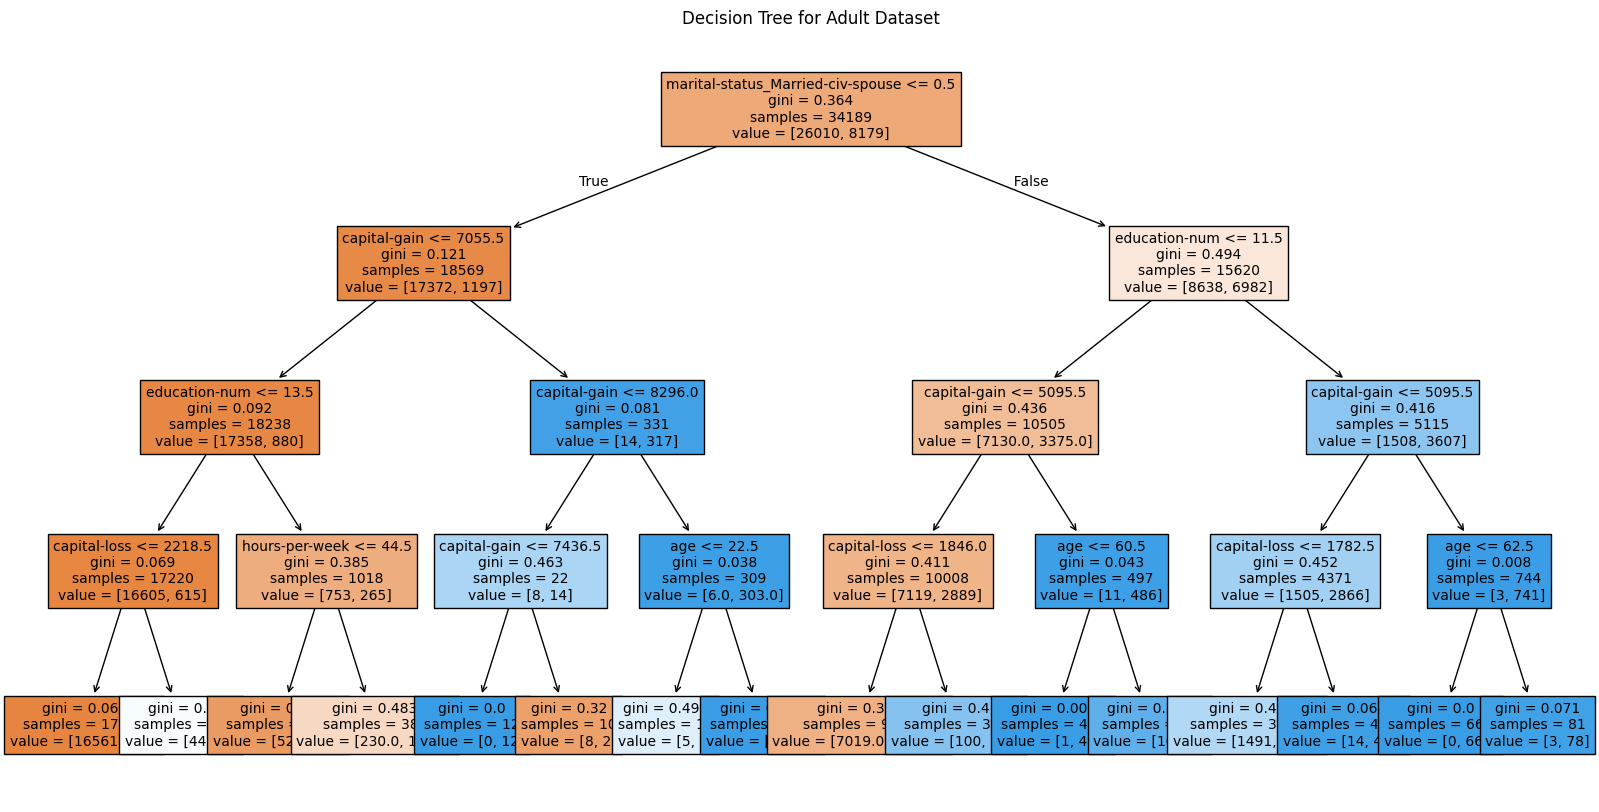

confusion matrix:
[[10368   777]
 [ 1514  1994]]

marital-status_Married-civ-spouse    49
capital-gain                         23
education-num                        22
capital-loss                          5
hours-per-week                        1
age                                   0
dtype: int64


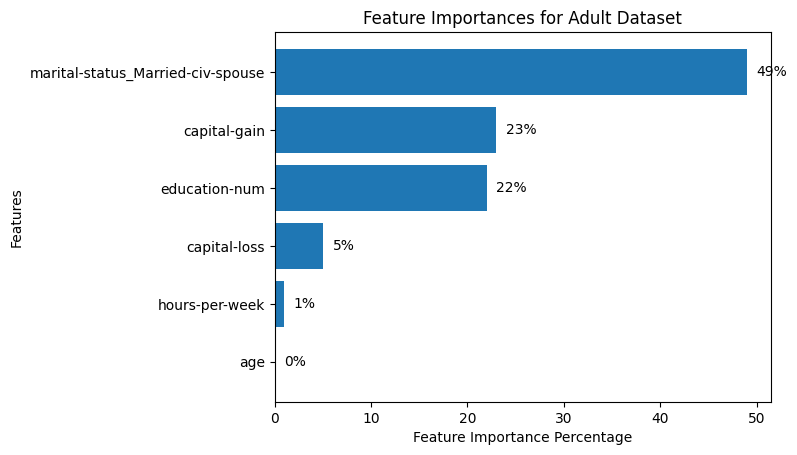

accuracy: 0.821470006142087
precision: 0.632817153067302
recall: 0.6057582668187002


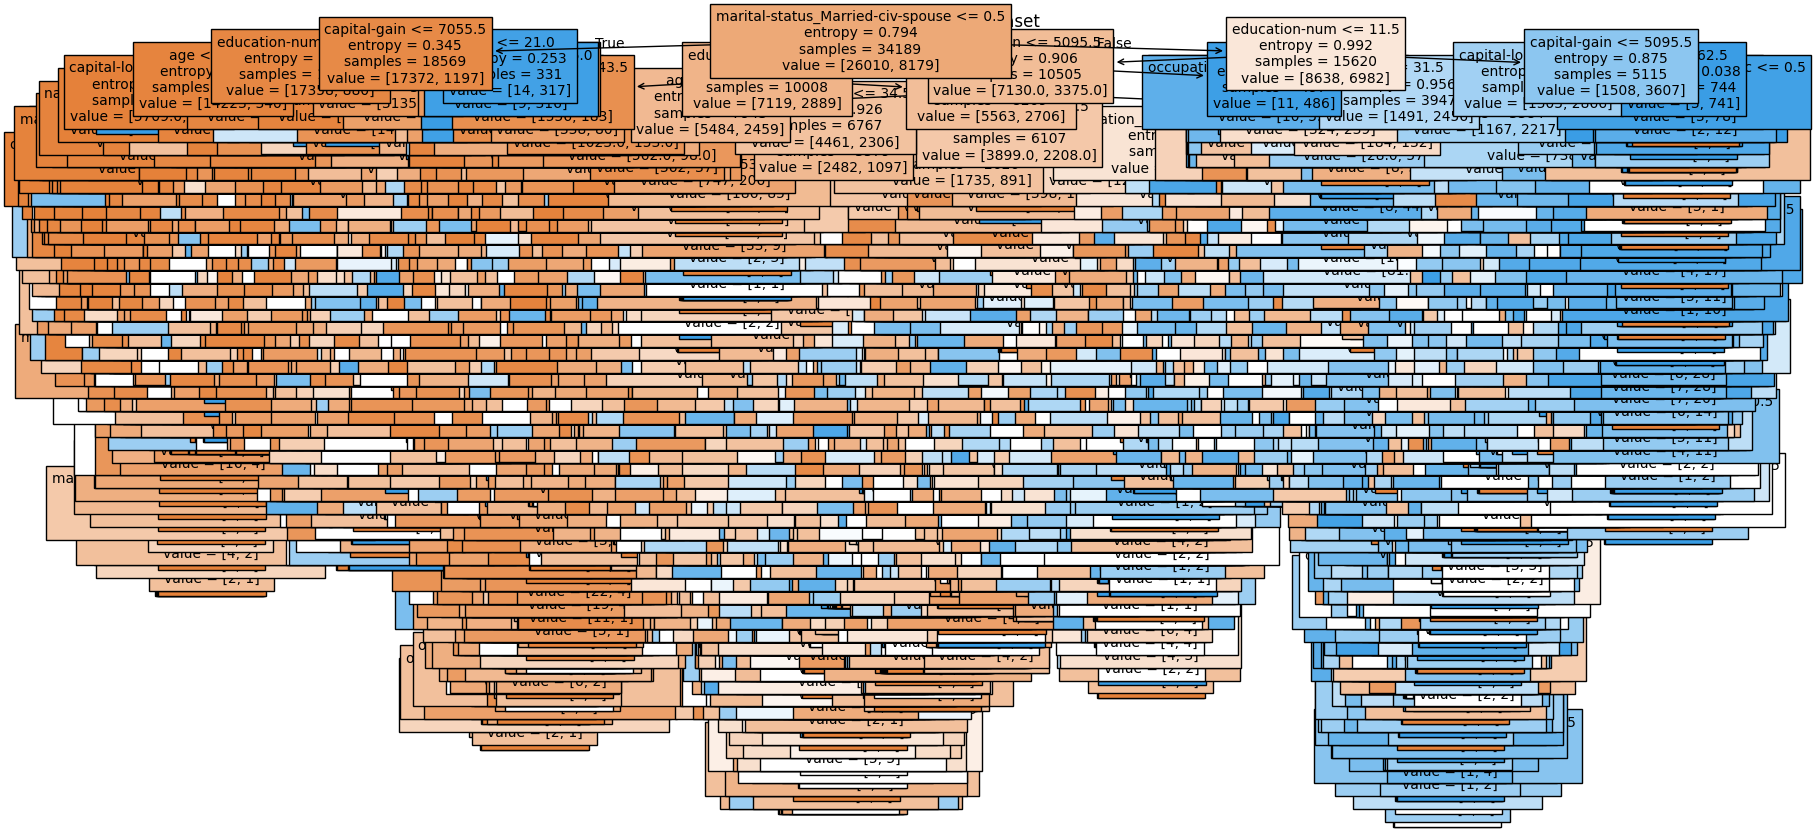

confusion matrix:
[[9912 1233]
 [1383 2125]]

marital-status_Married-civ-spouse    21
age                                  18
capital-gain                         11
education-num                        11
hours-per-week                       10
capital-loss                          4
dtype: int64


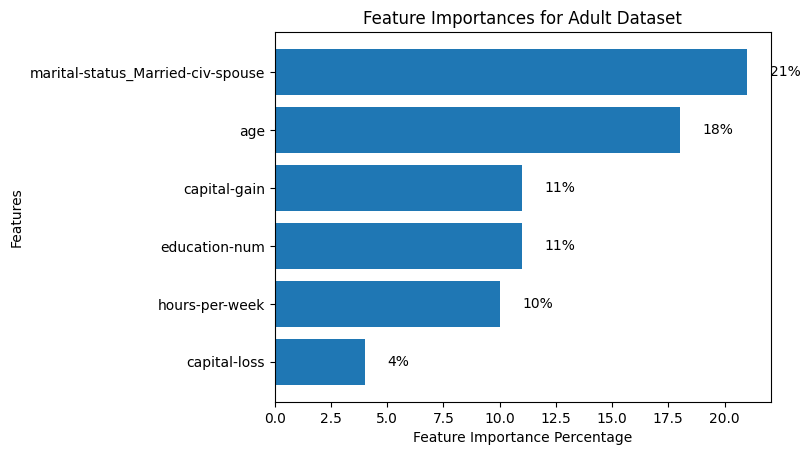

accuracy: 0.8514979867603903
precision: 0.7683319903303787
recall: 0.5436145952109465


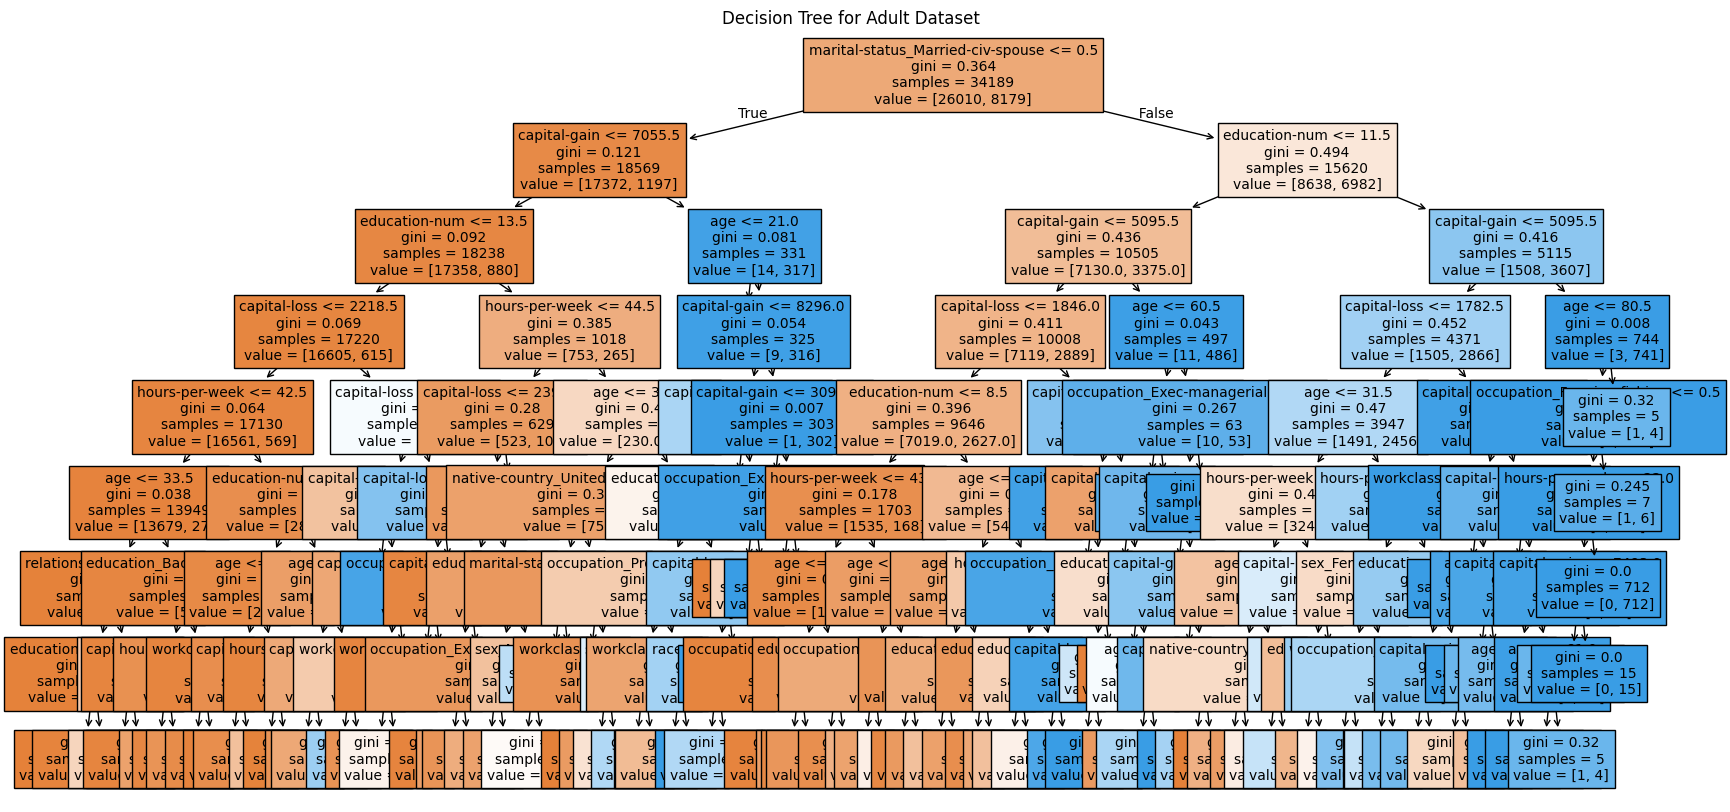

confusion matrix:
[[10570   575]
 [ 1601  1907]]

marital-status_Married-civ-spouse    41
education-num                        23
capital-gain                         20
capital-loss                          7
age                                   4
hours-per-week                        3
dtype: int64


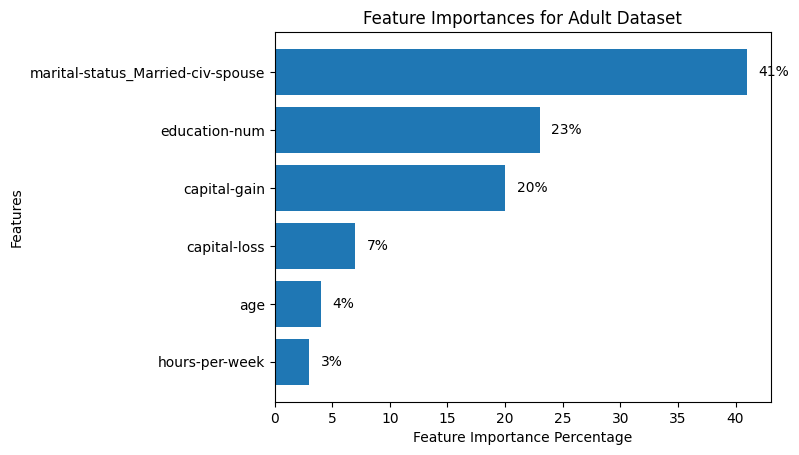

In [66]:
tree_fun(X_clean, y_clean_binary, max_depth_val=4, min_samples_split_val=20,
    min_samples_leaf_val=10) #highly pruned tree, adjusting min samples split and min samples leaf to reduce overfitting

tree_fun(X_clean,y_clean_binary, criterion_val='entropy') #want to compare performance of entropy

tree_fun(X_clean, y_clean_binary, max_depth_val=8, min_samples_split_val=10,min_samples_leaf_val=5) #test a more balanced tree, resulted in the highest accuracy metric
#I was surprised that all three options resulted in different percentages for the feature importances, but martial status was still the top feature.



# **Part 3: Random Forest and Ensembling Evaluation (40 Points)**

## For Parts 3 and 4, you may pick *your own dataset* or continue with the census data.

## Like above, you will want to reference the documentation as necessary:
### https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


## **Data**
## Use this space to load and call your data for Parts 3 and 4. You are welcome to use your final project data for these sections.

## **Question 1 (10 points):**

## Write a function to take in a feature variable (X) and a target variable (y). Create a train test split for the variables.

## Finally, instantiate, fit, and predict using **both** a single Decision Tree and a Random Forest classifier. Print the accuracy, precision, and recall for both models.

## Call your function and describe your baseline results.


In [67]:
def baseline(X, y):
     #TRAIN TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3001)
    
    #DECISION TREE MODEL (add parameters)
    treemodel=DecisionTreeClassifier(random_state=3001)
    treemodel.fit(X_train, y_train)
    tree_y_pred = treemodel.predict(X_test)
     
    #OBTAIN AND PRINT METRICS (accuracy, precision, recall)
    acc = accuracy_score(y_test, tree_y_pred)
    prec = precision_score(y_test, tree_y_pred, average='binary')
    rec = recall_score(y_test, tree_y_pred, average='binary')
    
    print("decision tree accuracy: "+str(acc))
    print("decision tree precision: "+str(prec))
    print("decision tree recall: "+str(rec))
     
    #RANDOM FOREST
    forestmodel = RandomForestClassifier(random_state=3001)
    forestmodel.fit(X_train, y_train)
    forest_y_pred = forestmodel.predict(X_test)
    
    #metrics for random forest
    rf_accuracy = accuracy_score(y_test, forest_y_pred)
    rf_precision = precision_score(y_test, forest_y_pred)
    rf_recall = recall_score(y_test, forest_y_pred)
    print()
    print("rf accuracy: "+str(rf_accuracy))
    print("rf precision: "+str(rf_precision))
    print("rf recall: "+str(rf_recall))
     
baseline(X_clean,y_clean_binary) #results have a relatively high accuracy, with the random forests metrics being higher overall
    
    


decision tree accuracy: 0.8188084351327374
decision tree precision: 0.6278860569715142
decision tree recall: 0.5969213226909921

rf accuracy: 0.8424213471644032
rf precision: 0.6920858699134893
rf recall: 0.6157354618015963



## **Question 2 (30 points):**
## This question will ask you to tune Random Forest classifiers and preprocess your data in *any number of ways* to achieve the *best possible results you can*.

## Train one vanilla Decision Forest model and one vanilla Random Forest model and store their accuracies in variables so you can use them as baselines.

## Then, using functions or not, spend some time tuning at least 10 (or more) Random Forest models. Store your accuracies in a list or array and print your maximum accuracy.

# **Go crazy - feel free to implement sampling, dropping features, preprocessing, new parameters, whatever might boost your accuracy.**

# **The top 5 best accuracies in the class will get +15 on their individual lab grade!**

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean_binary, test_size=0.3, random_state=3001)

#Baseline Decision Tree
baselinedt = DecisionTreeClassifier(random_state=3001)
baselinedt.fit(X_train, y_train)
dt_pred = baselinedt.predict(X_test)
baselineDT_acc = accuracy_score(y_test, dt_pred)
print('baseline decision tree accuracy: '+str(baselineDT_acc))

#Baseline Random Forest
baselinerf = RandomForestClassifier(random_state=3001)
baselinerf.fit(X_train, y_train)
rf_pred = baselinerf.predict(X_test)
baselineRF_acc = accuracy_score(y_test, rf_pred)
print('baseline random forest accuracy: '+str(baselineRF_acc))


#tuning random forest

#trying with many more trees
rf1=RandomForestClassifier(n_estimators=200,random_state=3001)
rf1.fit(X_train, y_train)
pred1= rf1.predict(X_test)
acc1 = accuracy_score(y_test,pred1)

rf2=RandomForestClassifier(n_estimators=500,random_state=3001)
rf2.fit(X_train, y_train)
pred2= rf2.predict(X_test)
acc2 = accuracy_score(y_test,pred2)

#different depths
rf3 = RandomForestClassifier(max_depth=10, random_state=3001)
rf3.fit(X_train, y_train)
pred3 = rf3.predict(X_test)
acc3 = accuracy_score(y_test, pred3)

rf4 = RandomForestClassifier(max_depth=30, random_state=3001)
rf4.fit(X_train, y_train)
pred4 = rf4.predict(X_test)
acc4=accuracy_score(y_test,pred4)

#higher min samples leaf
rf5 = RandomForestClassifier(min_samples_leaf=7, n_estimators=200, random_state=3001)
rf5.fit(X_train, y_train)
pred5 = rf5.predict(X_test)
acc5 = accuracy_score(y_test, pred5)

#larger min samples splkit
rf6 = RandomForestClassifier(min_samples_split=10, random_state=3001)
rf6.fit(X_train, y_train)
pred6 = rf6.predict(X_test)
acc6 = accuracy_score(y_test, pred6)

#trying different max features
rf7 = RandomForestClassifier(max_features="log2", random_state=3001)
rf7.fit(X_train, y_train)
pred7 = rf7.predict(X_test)
acc7 = accuracy_score(y_test, pred7)

#change bootstrapping to false
rf8 = RandomForestClassifier(bootstrap=False, n_estimators=200, random_state=3001)
rf8.fit(X_train, y_train)
pred8 = rf8.predict(X_test)
acc8 = accuracy_score(y_test, pred8) #


#balanced class weight
rf9 = RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=3001)
rf9.fit(X_train, y_train)
pred9 = rf9.predict(X_test)
acc9 = accuracy_score(y_test, pred9) 


#combining multiple
rf10 = RandomForestClassifier(min_samples_split=10, min_samples_leaf=7, n_estimators=200, random_state=3001)
rf10.fit(X_train, y_train)
pred10 = rf10.predict(X_test)
acc10 = accuracy_score(y_test, pred10)

rf11 = RandomForestClassifier(n_estimators=200, max_depth=15,min_samples_split=5, min_samples_leaf=2,random_state=3001)
rf11.fit(X_train, y_train)
pred11 = rf11.predict(X_test)
acc11 = accuracy_score(y_test, pred11)

acc_score_array=[acc1,acc2,acc3,acc4,acc5,acc6,acc7,acc8, acc9, acc10,acc11]
print(acc_score_array)

for i in range(len(acc_score_array)):
    print('rf'+str(i+1)+' accuracy: '+str(acc_score_array[i]))
    
best_index = np.argmax(acc_score_array) + 1
best_acc = max(acc_score_array)

print(f"Maximum accuracy: Model {best_index} with accuracy {best_acc}")


baseline decision tree accuracy: 0.8188084351327374
baseline random forest accuracy: 0.8424213471644032
[0.8432402920903569, 0.8428990650378761, 0.8535453490752747, 0.8522486862758479, 0.8572306012420665, 0.8568893741895858, 0.8416706476489456, 0.833822425441889, 0.8408517027229919, 0.8572306012420665, 0.8570941104210742]
rf1 accuracy: 0.8432402920903569
rf2 accuracy: 0.8428990650378761
rf3 accuracy: 0.8535453490752747
rf4 accuracy: 0.8522486862758479
rf5 accuracy: 0.8572306012420665
rf6 accuracy: 0.8568893741895858
rf7 accuracy: 0.8416706476489456
rf8 accuracy: 0.833822425441889
rf9 accuracy: 0.8408517027229919
rf10 accuracy: 0.8572306012420665
rf11 accuracy: 0.8570941104210742
Maximum accuracy: Model 5 with accuracy 0.8572306012420665


# **Part 4: Ensemble Model Interpretation and Reflection (15 Points)** 


## **Question 1 (5 points):**
## Create a plot that summarizes the results of your experiments and how they compare to the results of your baseline Decision Tree and Random Forest model.

## You may visualize your results in any type of plot you see fit. Color code your visual in some way so that models that did better than the baseline Random Forest are distinguished from models that did worse.

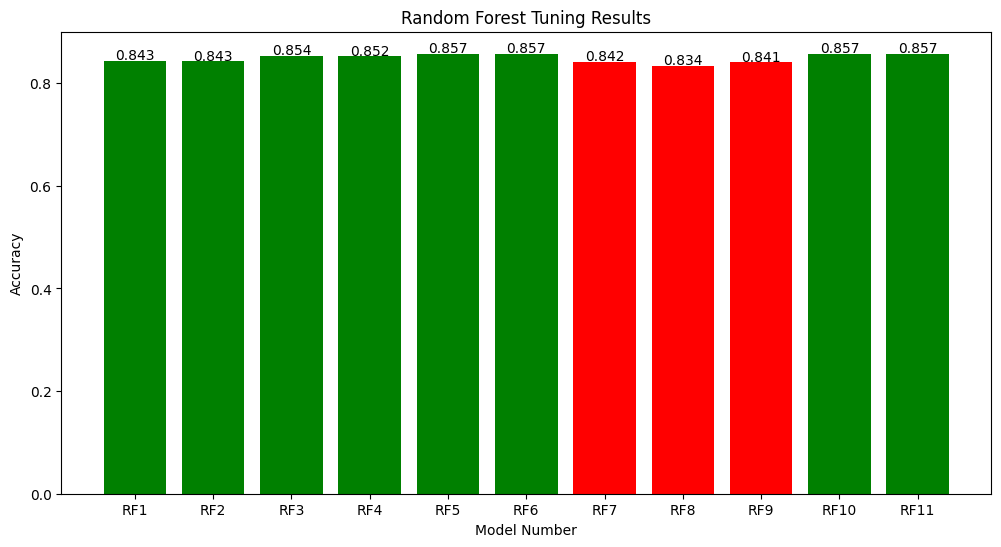

In [69]:
import matplotlib.pyplot as plt
import numpy as np

model_labels = [f"RF{i+1}" for i in range(len(acc_score_array))] ##labels for the tuned models
accs = np.array(acc_score_array) #accuracy array
colors = ['green' if acc > baselineRF_acc else 'red' for acc in accs] ##color the models, red if accuracy is lower than baseline rf

#make plot
plt.figure(figsize=(12, 6))
plt.bar(model_labels, accs, color=colors)
plt.ylabel("Accuracy")
plt.xlabel("Model Number")
plt.title("Random Forest Tuning Results")

for i, acc in enumerate(accs): #add accuracy values
    plt.text(i, acc + 0.002, f"{acc:.3f}", ha='center')



plt.show()


## **Question 2 (5 points):**
## Write 10 or more sentences on what parameters had the biggest effect or did not seem to effect your results. Did any parameter choices make your results worse than your vanilla model?

**The parameters I chose...
Increasing the number of estimators to 200 in my models resulted in a small increase in accuracy. However, increasing n_estimators beyond that did not lead to further improvement. Similarly, adjusting the maximum depth to 10 improved accuracy, but increasing it to 30 did not provide additional improvement. Changes to min_sample_leaf and min_sample_split had large effects on accuracy when tuned separately in models 5 and 6. However, combining these two parameters in mdoel 10 did not provide the highest accuracy. Model 5, which used min_samples_leaf=7 and n_estimators=200 achieved the highest result. Some parameter changes reduced performance compared to the baseline random forest. Model 7 set max_features=log2 and performed worse. Model 8 removed bootstrapping and also reduced accuracy. Finally, model 9, which used class_weight=balanced, decreased accuracy, suggesting that the dataset was not heavily imbalanced to begin with. Overall, the most impactful parameters were n_estimators and min_samples_leaf. 

**

## **Question 3 (5 points):**
## Write 10 or more sentences reflecting on the tuning process.

## What kind of approach did you take? Was it random combinations or more structured? Did you change your approach after seeing your initial results?

## What kind of strategies in preprocessing and picking parameters (ie: brute forcing parameters, testing various values in a range) do you think would get some of the best scores in the class?

**My approach to tuning...**

My approach during tuning was random at first but also structured. I first tried changing each parameter and observed effects on accuracy. After finding that changing some parameters such as increasing n_estimators improved performance, I tried combining parameters that were performing well in models 10 and 11. After that, I systematically tried increasing or changing parameters one at a time to find the ideal combination. Randomly changing parameters did not have a large effect on accuracy. I also noticed that some parameters, such as balanced class, had very little effect on accuracy, so I did not combine that with other parameters. Gridsearch would be a good method to finding an ideal combination for parameters rather than manually tuning. I think the best class scores would come from using gridsearch combined with different preprocessing techniques. Further preprocessing could include reducing outliers and unnecessary features. Overall, the tuning process showed that it can be difficult to manually decide effective parameters to increase accuracy. 

### Honor Pledge

On my honor as a student, I have neither given nor received unauthorized aid on this assignment.